# Experiment Summary → Enrichment
Dieses Notebook lädt das ausgelagerte Skript `predictions_enricher.py`, reichert die Summary an und lädt alle relevanten Daten für die anschließende Visualisierung.

In [3]:
# 1) Imports
from pathlib import Path
import pandas as pd
from predictions_enricher import enrich_summary

# # Optional: hübschere Anzeige
pd.set_option("display.max_columns", 0)


In [34]:
# 2) Parameter anpassen (Windows-Pfade sind ok)


BASE = r"C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Output"

BASE = r"C:\DEV\RevPi_ML\ML_Edge_Device\Output"  # ← anpassen

SUMMARY_FILE = "Experiment_Summary.csv"  # ← anpassen

SUMMARY_FILE = r"Experiment_Summary_Server_multiconfig_test.csv"

SUMMARY_FILE = r"Experiment_Summary_Server_multiconfig_Final.csv"


OUT_FILE = "Experiment_Enriched_SingleMetricKachel.csv"     # optional

# Ausrichtung der Horizons: "t_plus_h" (default) oder "t_plus_h_minus_1"
SHIFT_MODE = "t_plus_h"

# Ob Error_Metrics JSON (mse/r2 + training_time_s + model_sizes_mb) mit angehängt werden soll
INCLUDE_JSON = True


import importlib, predictions_enricher
importlib.reload(predictions_enricher)
# 3) Enrichment laufen lassen
df_out = predictions_enricher.enrich_summary(
    base=BASE,
    summary_file=SUMMARY_FILE,
    out_file=OUT_FILE,
    shift_mode=SHIFT_MODE,
    drop_old_metrics=True,
    include_error_json=True,
)

print(f"Enriched rows: {len(df_out)}")
df_out.head(3)


BASE_multi_server = r"C:\DEV\RevPi_ML\ML_Edge_Device\Output"
SUMMARY_FILE_multi_server = r"Experiment_Summary_Server_multiconfig_Final.csv"

df_multiconfig_server = predictions_enricher.enrich_summary(
    base=BASE_multi_server,
    summary_file=SUMMARY_FILE_multi_server,
    out_file=OUT_FILE,
    shift_mode=SHIFT_MODE,
    drop_old_metrics=True,
    include_error_json=True,
)

BASE_multi_edge = r"C:\DEV\RevPi_ML\zwischenergebnisse_final"
SUMMARY_FILE_multi_edge = r"Experiment_Summary_Server_multiconfig_Final.csv"

df_multiconfig_edge = predictions_enricher.enrich_summary(
    base=BASE_multi_edge,
    summary_file=SUMMARY_FILE_multi_edge,
    out_file=OUT_FILE,
    shift_mode=SHIFT_MODE,
    drop_old_metrics=True,
    include_error_json=True,
)



df_multiconfig_server

OK: Nur MAE/R² aus Predictions übernommen → C:\DEV\RevPi_ML\ML_Edge_Device\Output\Analysis\Experiment_Enriched_SingleMetricKachel.csv
Enriched rows: 231
OK: Nur MAE/R² aus Predictions übernommen → C:\DEV\RevPi_ML\ML_Edge_Device\Output\Analysis\Experiment_Enriched_SingleMetricKachel.csv
OK: Nur MAE/R² aus Predictions übernommen → C:\DEV\RevPi_ML\zwischenergebnisse_final\Analysis\Experiment_Enriched_SingleMetricKachel.csv


,algorithm,level,lags,horizon,model_variant,quant_mode,avg_inference_time_ms,avg_total_time_ms,avg_cpu_percent,avg_ram_percent,...,mae_h15_from_preds,r2_h15_from_preds,mae_h16_from_preds,r2_h16_from_preds,mae_h17_from_preds,r2_h17_from_preds,mae_h18_from_preds,r2_h18_from_preds,mae_h19_from_preds,r2_h19_from_preds
0,cnn1d,simple,20,1,model.keras,no-quant,62.257097,90.737252,9.045800,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cnn1d,simple,20,1,model_quant_float16.tflite,quant-16,0.199971,29.076699,8.484811,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,cnn1d,simple,20,1,model_quant_int8_full.tflite,quant-8,0.210397,29.238800,8.019546,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,cnn1d,medium,20,1,model.keras,no-quant,62.671866,90.876983,8.854365,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,cnn1d,medium,20,1,model_quant_float16.tflite,quant-16,0.101078,29.380791,8.036934,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,svm,medium,20,16,model.joblib,no-quant,2.246782,34.484661,8.049571,31.9,...,1.007310,0.444144,0.998053,0.449158,NaN,NaN,NaN,NaN,NaN,NaN
227,svm,high,20,16,model.joblib,no-quant,2.306595,37.476441,7.887950,31.9,...,1.003754,0.447938,0.996048,0.447549,NaN,NaN,NaN,NaN,NaN,NaN
228,svm,simple,20,19,model.joblib,no-quant,2.345810,34.726585,8.118485,31.9,...,1.006618,0.444145,0.997414,0.448562,1.030210,0.430304,1.033516,0.424515,1.025535,0.459717
229,svm,medium,20,19,model.joblib,no-quant,2.460812,33.312105,8.370904,31.9,...,1.006639,0.447024,0.998556,0.447457,1.028130,0.433698,1.032704,0.424278,1.024714,0.458998


### Hinweis zur Visualisierung
Ab hier können direkt Visualisierungen erstellt werden (z. B. Verteilung von `mae_from_preds`, Vergleich der Quantisierungen über `err_model_size_mb` vs. `err_mse` usw.).

In [7]:
# === Build a slim tile from df_out (does NOT modify df_out) ===
import re
import numpy as np
import pandas as pd
from pathlib import Path

def _infer_quant_mode(model_variant: str) -> str:
    s = str(model_variant or "").lower()
    if "no-quant" in s or "no_quant" in s: return "no-quant"
    if "int8" in s or "quant_int8" in s:   return "int8"
    if any(t in s for t in ["float16","fp16","quant_float16"]): return "float16"
    if any(t in s for t in ["joblib",".joblib",".pkl",".sav","sklearn"]): return "joblib"
    if any(t in s for t in ["keras","model.keras","model_keras"]): return "keras"
    return ""

tile = df_out.copy()

# quant_mode ergänzen/fixen
if "quant_mode" not in tile.columns:
    tile["quant_mode"] = tile.get("model_variant", "").map(_infer_quant_mode)
else:
    # leere quant_mode-Zellen ggf. aus model_variant ableiten
    m = tile["quant_mode"].astype(str).str.strip()
    need = (m.eq("") | m.isna())
    if need.any():
        tile.loc[need, "quant_mode"] = tile.loc[need, "model_variant"].map(_infer_quant_mode)

# model_size_mb fallback, falls nicht vorhanden
if "model_size_mb" not in tile.columns:
    for alt in ["err_model_size_mb","model_size_MB","model_sizeMB"]:
        if alt in tile.columns:
            tile["model_size_mb"] = pd.to_numeric(tile[alt], errors="coerce")
            break
if "model_size_mb" not in tile.columns:
    tile["model_size_mb"] = np.nan

# Stammdaten (nur vorhandene behalten)
base_cols = [
    "model_variant","algorithm","level","lags","horizon",
    "quant_mode","avg_inference_time_ms","model_size_mb",
]
base_cols = [c for c in base_cols if c in tile.columns]

# alle MAE/R²-Metriken dynamisch einsammeln
metric_cols = [c for c in tile.columns if re.match(
    r"^(mae|r2)_(h\d+_from_preds|from_preds|all_(avg|pooled)_from_preds)$", c
)]

# Reihenfolge festlegen: h1 → Aggregationen → from_preds → restliche Horizonte (h2..hN)
ordered_metrics = []
if "mae_h1_from_preds" in metric_cols: ordered_metrics.append("mae_h1_from_preds")
if "r2_h1_from_preds"  in metric_cols: ordered_metrics.append("r2_h1_from_preds")
for agg in ["mae_all_avg_from_preds","r2_all_avg_from_preds",
            "mae_all_pooled_from_preds","r2_all_pooled_from_preds"]:
    if agg in metric_cols: ordered_metrics.append(agg)
for z in ["mae_from_preds","r2_from_preds"]:
    if z in metric_cols: ordered_metrics.append(z)
# restliche Horizonte sortiert
h_rest = sorted({
    int(m.group(1)) for c in metric_cols
    if (m := re.search(r"^mae_h(\d+)_from_preds$", c)) and int(m.group(1)) != 1
}.union({
    int(m.group(1)) for c in metric_cols
    if (m := re.search(r"^r2_h(\d+)_from_preds$", c)) and int(m.group(1)) != 1
}))
for h in h_rest:
    mh, rh = f"mae_h{h}_from_preds", f"r2_h{h}_from_preds"
    if mh in metric_cols: ordered_metrics.append(mh)
    if rh in metric_cols: ordered_metrics.append(rh)

wanted_cols = base_cols + ordered_metrics
tile_df = tile.reindex(columns=wanted_cols)

# Metriken als numerisch casten
for c in ordered_metrics:
    tile_df[c] = pd.to_numeric(tile_df[c], errors="coerce")

# anzeigen
print("Tile shape:", tile_df.shape)
display(tile_df.head(10))

# optional speichern
# out_path = Path(BASE) / "Analysis" / "Experiment_Metrics_Tile.csv"
# tile_df.to_csv(out_path, index=False, encoding="utf-8")
# print("Tile gespeichert:", out_path)

# Wenn du df_out ersetzen willst (optional):
# df_out = tile_df


Tile shape: (216, 44)


,model_variant,algorithm,level,lags,horizon,quant_mode,avg_inference_time_ms,model_size_mb,mae_h1_from_preds,r2_h1_from_preds,...,mae_h11_from_preds,r2_h11_from_preds,mae_h12_from_preds,r2_h12_from_preds,mae_h13_from_preds,r2_h13_from_preds,mae_h14_from_preds,r2_h14_from_preds,mae_h15_from_preds,r2_h15_from_preds
0,model.joblib,light_xgboost,simple,20,1,no-quant,87.382783,0.6516,0.895751,0.587999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,model.joblib,light_xgboost,medium,20,1,no-quant,77.913183,0.7034,0.789498,0.702376,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,model.joblib,light_xgboost,high,20,1,no-quant,76.390421,1.2397,0.616462,0.705597,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,model.joblib,light_xgboost,simple,20,3,no-quant,83.811376,1.9524,0.898292,0.582462,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,model.joblib,light_xgboost,medium,20,3,no-quant,83.920014,2.1076,0.792947,0.698397,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,model.joblib,light_xgboost,high,20,3,no-quant,84.155576,3.7145,0.615560,0.731311,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,model.joblib,light_xgboost,simple,20,5,no-quant,91.810928,3.2513,0.883910,0.602072,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,model.joblib,light_xgboost,medium,20,5,no-quant,91.571359,3.5128,0.804761,0.691264,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,model.joblib,light_xgboost,high,20,5,no-quant,102.866831,6.1968,0.664397,0.688799,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,model.joblib,light_xgboost,simple,20,7,no-quant,92.985424,4.5524,0.891418,0.588732,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,algorithm,level,lags,horizon,model_variant,quant_mode,avg_inference_time_ms,avg_total_time_ms,avg_cpu_percent,avg_ram_percent,...,mae_h11_from_preds,r2_h11_from_preds,mae_h12_from_preds,r2_h12_from_preds,mae_h13_from_preds,r2_h13_from_preds,mae_h14_from_preds,r2_h14_from_preds,mae_h15_from_preds,r2_h15_from_preds
0,light_xgboost,simple,20,1,model.joblib,no-quant,87.382783,132.975563,44.045104,45.723333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,light_xgboost,medium,20,1,model.joblib,no-quant,77.913183,127.477420,40.552469,45.700000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,light_xgboost,high,20,1,model.joblib,no-quant,76.390421,124.974143,38.589831,45.723333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,light_xgboost,simple,20,3,model.joblib,no-quant,83.811376,131.922520,41.142403,45.700000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,light_xgboost,medium,20,3,model.joblib,no-quant,83.920014,133.440107,42.725968,45.700000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,lstm,medium,20,15,model_quant_float16.tflite,quant-16,0.774231,27.053697,8.069931,46.592600,...,1.023915,0.615813,1.057970,0.602304,1.080600,0.583574,1.077545,0.587573,1.067409,0.588166
212,lstm,medium,20,15,model_quant_int8_full.tflite,quant-8,1.950558,28.780159,8.189581,46.519400,...,1.026081,0.615091,1.069037,0.602788,1.084657,0.582548,1.081537,0.586432,1.066954,0.587327
213,lstm,high,20,15,model.keras,no-quant,59.147162,85.388861,8.871329,46.540400,...,1.080827,0.618606,1.068474,0.613408,1.134561,0.598666,1.143722,0.572727,1.098245,0.614337
214,lstm,high,20,15,model_quant_float16.tflite,quant-16,0.768687,26.996230,8.167220,46.500000,...,1.080941,0.618607,1.068442,0.613401,1.134511,0.598664,1.143741,0.572722,1.098204,0.614341


Trade-off scatter plot has been generated and saved as 'tradeoff_performance_vs_time.png'.


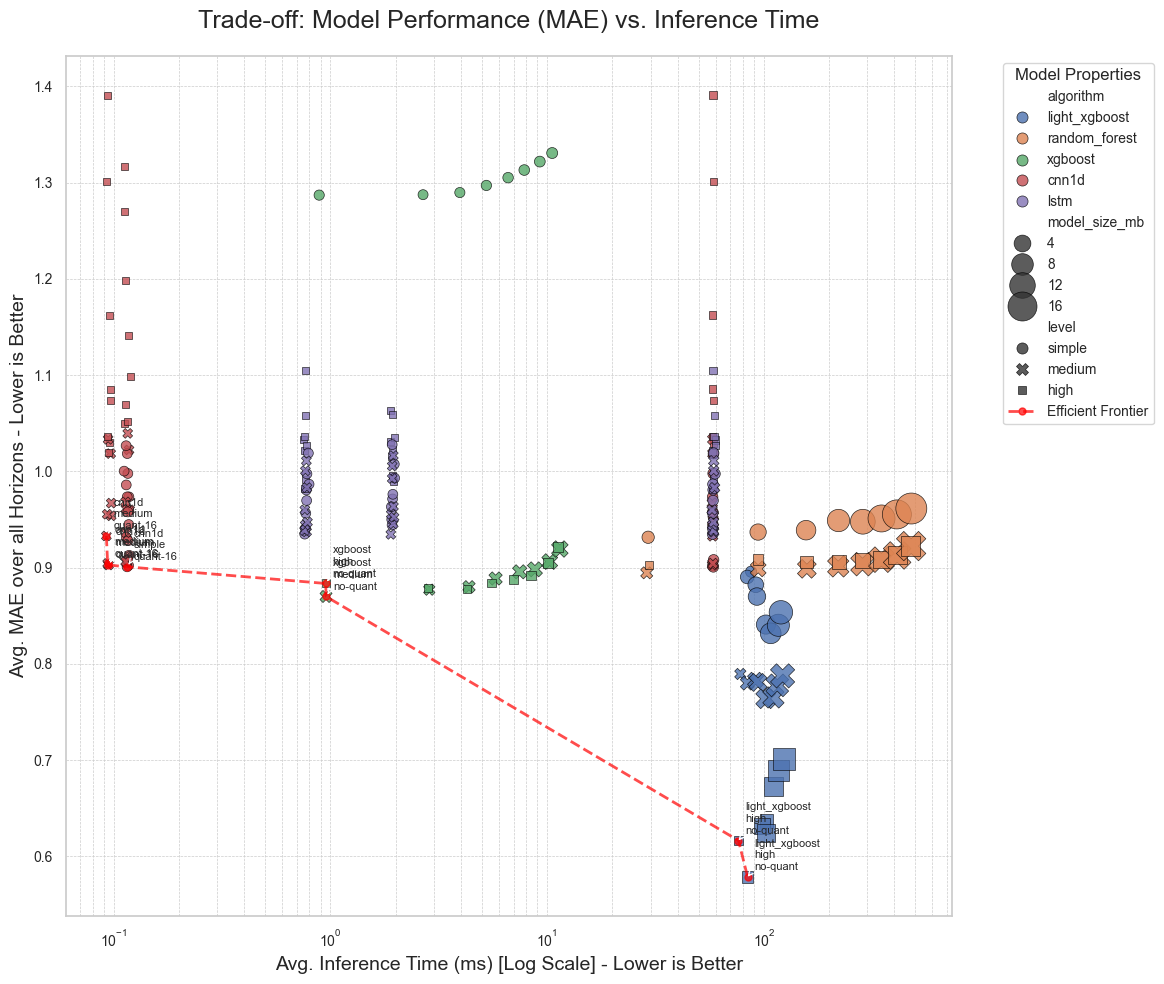

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = tile
# --- Plotting ---
plt.figure(figsize=(14, 10))

# Use seaborn for a rich scatter plot that handles legends well
ax = sns.scatterplot(
    data=df,
    x='avg_inference_time_ms',
    y='mae_all_avg_from_preds',
    hue='algorithm',
    style='level',
    size='model_size_mb',
    sizes=(50, 500), # Range of bubble sizes
    palette='deep',
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5
)

# --- Enhancements ---
plt.title('Trade-off: Model Performance (MAE) vs. Inference Time', fontsize=18, pad=20)
plt.xlabel('Avg. Inference Time (ms) - Lower is Better', fontsize=14)
plt.ylabel('Avg. MAE over all Horizons - Lower is Better', fontsize=14)

# Use a logarithmic scale for the x-axis if the values have a wide range
# Check if the range is large enough to warrant a log scale
if df['avg_inference_time_ms'].max() / df['avg_inference_time_ms'].min() > 10:
    plt.xscale('log')
    plt.xlabel('Avg. Inference Time (ms) [Log Scale] - Lower is Better', fontsize=14)


# Find and annotate the "Pareto front" points
# A point is on the front if no other point is better on both axes (lower x and lower y)
pareto_front = []
for index, row in df.iterrows():
    is_pareto = True
    # Check if any other point dominates this one
    for i2, r2 in df.iterrows():
        if i2 != index:
            if r2['avg_inference_time_ms'] <= row['avg_inference_time_ms'] and r2['mae_all_avg_from_preds'] <= row['mae_all_avg_from_preds']:
                # Strict dominance check (better on at least one axis)
                if r2['avg_inference_time_ms'] < row['avg_inference_time_ms'] or r2['mae_all_avg_from_preds'] < row['mae_all_avg_from_preds']:
                    is_pareto = False
                    break
    if is_pareto:
        pareto_front.append(row)

if pareto_front:
    df_pareto = pd.DataFrame(pareto_front)
    df_pareto = df_pareto.sort_values(by='avg_inference_time_ms')
    
    # Plot the Pareto front line
    plt.plot(df_pareto['avg_inference_time_ms'], df_pareto['mae_all_avg_from_preds'], color='red', linestyle='--', marker='o', markersize=5, alpha=0.7, label='Efficient Frontier')

    # Annotate points on the front
    for index, row in df_pareto.iterrows():
        label = f"{row['algorithm']}\n{row['level']}\n{row['quant_mode']}"
        plt.annotate(label, 
                     (row['avg_inference_time_ms'], row['mae_all_avg_from_preds']),
                     textcoords="offset points",
                     xytext=(5,5),
                     ha='left',
                     fontsize=8,
                     arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))


# Adjust legend position
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Model Properties')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout for legend

# Save the plot
plt.savefig('tradeoff_performance_vs_time.png', bbox_inches='tight')

print("Trade-off scatter plot has been generated and saved as 'tradeoff_performance_vs_time.png'.")

In [36]:
# Time vs. MAE_avg per Level — Notebook Cell (supports dual source)
# -----------------------------------------------------------------
# Standard: df = tile
# Optional (DUAL_SOURCE=True): df_server und df_edge verwenden
#
# Visualisiert pro (Modell, Quantisierungsmodus) den Zusammenhang:
#   x = Ø Inferenzzeit (ms), y = MAE Ø(H)
#   • Punkte = einzelne Horizonte (H) pro Level
#   • Rauten + Fehlerbalken = Level-Mittelwert ± Std (x & y)

from __future__ import annotations
import re
from pathlib import Path
from typing import Iterable, Optional, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Konfiguration ----------
OUTPUT_DIR     = "plots_time_vs_mae"
WRITE_SUMMARY  = True
MARKER_ALPHA   = 0.35
DUAL_SOURCE    = False  # <- auf True setzen, um df_server (MAE) + df_edge (Zeit) zu nutzen

# Wenn DUAL_SOURCE=True, erwarte im Notebook:
# df_server  -> enthält MAE_avg
# df_edge    -> enthält Inferenzzeiten


# ---------- Utils ----------
def _resolve_col(df: pd.DataFrame, candidates: Iterable[str], required: bool = True, default: Optional[str] = None) -> Optional[str]:
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Keine der erwarteten Spalten gefunden: {list(candidates)}")
    return default

def _canon_level(x: object) -> str:
    s = str(x).strip().lower()
    if s.startswith("h"): return "High"
    if s.startswith("m"): return "Medium"
    if s.startswith("s"): return "Simple"
    return str(x).title()

def _sanitize_name(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(s))

def _ensure_dir(p: Path) -> Path:
    p.mkdir(parents=True, exist_ok=True)
    return p


# ---------- Normalisierung / Spaltenauflösung ----------
def _normalize_with_mapping(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, Optional[str]]]:
    """Normalisiert df (Level, H, quant_mode) und löst Spaltennamen robust auf."""
    df = df.copy()

    col_model = _resolve_col(df, ["algorithm", "model", "algo"])
    col_level = _resolve_col(df, ["level", "complexity"])
    col_h     = _resolve_col(df, ["horizon", "H", "HORIZON"])
    col_qmode = _resolve_col(df, ["quant_mode", "quantization_mode", "quantization", "quant_mode_str"],
                             required=False, default="__NO_COL__")

    col_time  = _resolve_col(df, ["avg_inference_time_ms", "avg_inference_time", "inference_time_ms", "mean_inference_time_ms"], required=False)
    col_ma_all= _resolve_col(df, ["mae_all_avg_from_preds", "MAE_all_avg_from_preds", "mae_all_avg", "metrics_value.mae_all_avg"], required=False)
    col_ma    = _resolve_col(df, ["metrics_value.mae", "mae", "MAE"], required=False)

    # MAE-Ø(H) Fallback
    if col_ma_all is None and col_ma is not None:
        df["__mae_all_fallback__"] = df[col_ma]
        col_ma_all = "__mae_all_fallback__"

    # Werte normieren
    df[col_level] = df[col_level].map(_canon_level)
    df[col_h] = pd.to_numeric(df[col_h], errors="coerce")
    df = df.dropna(subset=[col_h])
    df[col_h] = df[col_h].astype(int)

    if col_qmode == "__NO_COL__":
        df["__quant_mode__"] = "no-quant"
        col_qmode = "__quant_mode__"
    else:
        df[col_qmode] = df[col_qmode].fillna("no-quant").astype(str)

    cols = dict(
        model=col_model, level=col_level, horizon=col_h, qmode=col_qmode,
        inftime=col_time, mae_all=col_ma_all
    )
    return df, cols


# ---------- Vorbereitung: Single-Source ----------
def _prepare_single(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, str]]:
    df_norm, cols = _normalize_with_mapping(df)
    if cols["inftime"] is None:
        raise KeyError("Inferenzzeit-Spalte nicht gefunden (z. B. 'avg_inference_time_ms').")
    if cols["mae_all"] is None:
        raise KeyError("MAE-Ø(H)-Spalte nicht gefunden (z. B. 'mae_all_avg_from_preds' oder Fallback 'mae').")
    return df_norm, cols  # Rohpunkte (keine Aggregation), ideal für Streuung


# ---------- Vorbereitung: Dual-Source (Server=MAE, Edge=Zeit) ----------
def _prepare_dual(df_server: pd.DataFrame, df_edge: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, str]]:
    ds, cs = _normalize_with_mapping(df_server)
    de, ce = _normalize_with_mapping(df_edge)

    if cs["mae_all"] is None:
        raise KeyError("Im df_server fehlt die MAE-Ø(H)-Spalte (z. B. 'mae_all_avg_from_preds').")
    if ce["inftime"] is None:
        raise KeyError("Im df_edge fehlt die Inferenzzeit-Spalte (z. B. 'avg_inference_time_ms').")

    keys = [cs["model"], cs["level"], cs["horizon"], cs["qmode"]]

    # Mittel über Runs je Schlüssel (Server -> MAE, Edge -> Zeit)
    s_sel = ds[keys + [cs["mae_all"]]].groupby(keys, dropna=False).mean(numeric_only=True).reset_index()
    e_sel = de[[ce["model"], ce["level"], ce["horizon"], ce["qmode"], ce["inftime"]]].groupby(
                [ce["model"], ce["level"], ce["horizon"], ce["qmode"]], dropna=False
            ).mean(numeric_only=True).reset_index()

    # Join (nur Keys, die in beiden vorkommen)
    merged = pd.merge(
        s_sel,
        e_sel,
        left_on=keys,
        right_on=[ce["model"], ce["level"], ce["horizon"], ce["qmode"]],
        how="inner",
        suffixes=("_server", "_edge")
    )

    # Einheitliche Spaltennamen für Plot
    merged = merged.rename(columns={
        cs["model"]:  "model",
        cs["level"]:  "level",
        cs["horizon"]:"horizon",
        cs["qmode"]:  "qmode",
        cs["mae_all"]:"mae_all_avg",
        ce["inftime"]:"inftime_ms",
    })

    cols = dict(model="model", level="level", horizon="horizon", qmode="qmode",
                inftime="inftime_ms", mae_all="mae_all_avg")
    return merged, cols


# ---------- Plot ----------
def _plot_levels(df_data: pd.DataFrame, cols: Dict[str, str],
                 output_dir: str | Path, write_summary: bool, marker_alpha: float) -> Dict[str, List[str]]:
    base_out = _ensure_dir(Path(output_dir))
    results: Dict[str, List[str]] = {"plots": []}
    if write_summary:
        results["summaries"] = []

    cM, cL, cH, cQ, cT, cA = cols["model"], cols["level"], cols["horizon"], cols["qmode"], cols["inftime"], cols["mae_all"]
    level_order = ["Simple", "Medium", "High"]

    for model_name, df_m in df_data.groupby(cM):
        for qmode, df_m_q in df_m.groupby(cQ):
            fig, ax = plt.subplots(figsize=(10.5, 7.5), dpi=150)

            # Punktwolken je Level
            for lvl in level_order:
                part = df_m_q[df_m_q[cL] == lvl].dropna(subset=[cT, cA])
                if part.empty:
                    continue
                ax.scatter(part[cT], part[cA], alpha=marker_alpha, label=f"{lvl} (Punkte = H)")

            # Level-Zentren + Std
            cent_rows = []
            for lvl in level_order:
                part = df_m_q[df_m_q[cL] == lvl].dropna(subset=[cT, cA])
                if part.empty:
                    continue
                x_mean = float(part[cT].mean())
                y_mean = float(part[cA].mean())
                x_std  = float(part[cT].std(ddof=1)) if len(part) >= 2 else 0.0
                y_std  = float(part[cA].std(ddof=1)) if len(part) >= 2 else 0.0

                ax.errorbar([x_mean], [y_mean], xerr=[[x_std]], yerr=[[y_std]],
                            fmt="D", markersize=7, capsize=4, label=f"{lvl} (Mittel±SD)")
                ax.annotate(lvl, (x_mean, y_mean), xytext=(6, 6), textcoords="offset points", fontsize=9)

                if write_summary:
                    cent_rows.append({
                        "model": model_name,
                        "quant_mode": qmode,
                        "level": lvl,
                        "n_points": len(part),
                        "mean_inference_time_ms": x_mean,
                        "std_inference_time_ms": x_std,
                        "mean_mae_all_avg": y_mean,
                        "std_mae_all_avg": y_std,
                    })

            ax.set_xlabel("Ø Inferenzzeit (ms)")
            ax.set_ylabel("MAE Ø(H)")
            ax.set_title(f"{model_name} — {qmode}\nInferenzzeit vs. MAE Ø(H) über Level (H als Punkte, Level-Mittel als Raute)")
            ax.grid(True, linestyle=":", linewidth=0.7)
            ax.legend(loc="best", fontsize=9)
            fig.tight_layout()

            out_dir = _ensure_dir(base_out / _sanitize_name(model_name) / _sanitize_name(str(qmode)))
            png = out_dir / f"{_sanitize_name(model_name)}__{_sanitize_name(str(qmode))}__TIME_vs_MAEAVG_LEVELS.png"
            pdf = out_dir / f"{_sanitize_name(model_name)}__{_sanitize_name(str(qmode))}__TIME_vs_MAEAVG_LEVELS.pdf"
            fig.savefig(png, bbox_inches="tight", dpi=300)
            fig.savefig(pdf, bbox_inches="tight", dpi=300)
            plt.close(fig)

            results["plots"] += [str(png), str(pdf)]

            if write_summary and cent_rows:
                cent_df = pd.DataFrame(cent_rows)
                csv_path = out_dir / f"{_sanitize_name(model_name)}__{_sanitize_name(str(qmode))}__TIME_vs_MAEAVG_LEVELS_summary.csv"
                cent_df.to_csv(csv_path, index=False)
                results["summaries"].append(str(csv_path))

    return results


# ---------- AUSFÜHRUNG IN DER NOTEBOOK-KACHEL ----------
DUAL_SOURCE = False
if DUAL_SOURCE:
    try:
        df_multiconfig_server  # noqa: F821
        df_multiconfig_edge    # noqa: F821
    except NameError as e:
        raise NameError("DUAL_SOURCE=True ist gesetzt, aber 'df_server' und/oder 'df_edge' sind im Notebook nicht definiert.") from e

    df_data, cols = _prepare_dual(df_multiconfig_server, df_multiconfig_edge)
else:
    try:
        df_multiconfig_server  # noqa: F821
    except NameError as e:
        raise NameError("DUAL_SOURCE=False: Erwartet ein DataFrame 'tile' im Notebook.") from e

    df_data, cols = _prepare_single(df_multiconfig_server)

res = _plot_levels(df_data, cols, OUTPUT_DIR, WRITE_SUMMARY, MARKER_ALPHA)

print("Fertig.")
print("Plots:", len(res["plots"]))
if WRITE_SUMMARY:
    print("Summaries:", len(res.get("summaries", [])))


Fertig.
Plots: 22
Summaries: 11


In [22]:
df_multiconfig_edge


,algorithm,level,lags,horizon,model_variant,quant_mode,avg_inference_time_ms,avg_total_time_ms,avg_cpu_percent,avg_ram_percent,...,mae_h11_from_preds,r2_h11_from_preds,mae_h12_from_preds,r2_h12_from_preds,mae_h13_from_preds,r2_h13_from_preds,mae_h14_from_preds,r2_h14_from_preds,mae_h15_from_preds,r2_h15_from_preds
0,cnn1d,simple,20,1,model.keras,no-quant,174.349152,261.893884,25.414395,55.238000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cnn1d,simple,20,1,model_quant_float16.tflite,quant-16,0.573647,82.456474,25.444349,46.796000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,cnn1d,simple,20,1,model_quant_int8_full.tflite,quant-8,0.580147,83.477392,25.788850,46.922000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,cnn1d,medium,20,1,model.keras,no-quant,172.689926,257.808212,25.472620,57.546667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,cnn1d,medium,20,1,model_quant_float16.tflite,quant-16,0.471869,82.666849,25.621620,51.212667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,light_xgboost,medium,20,13,model.joblib,no-quant,83.032031,168.133492,28.102035,68.433333,...,1.867604,0.0,1.831329,0.0,1.896829,0.0,NaN,NaN,NaN,NaN
212,light_xgboost,high,20,13,model.joblib,no-quant,90.699248,174.973520,28.076381,66.800000,...,1.739624,0.0,1.395367,0.0,2.148265,0.0,NaN,NaN,NaN,NaN
213,light_xgboost,simple,20,15,model.joblib,no-quant,94.464395,182.693805,28.239898,71.433333,...,1.496850,0.0,1.619767,0.0,1.677656,0.0,1.654412,0.0,1.793305,0.0
214,light_xgboost,medium,20,15,model.joblib,no-quant,99.277963,186.145108,27.974617,66.976667,...,1.871587,0.0,1.799668,0.0,1.918084,0.0,2.100165,0.0,2.056023,0.0


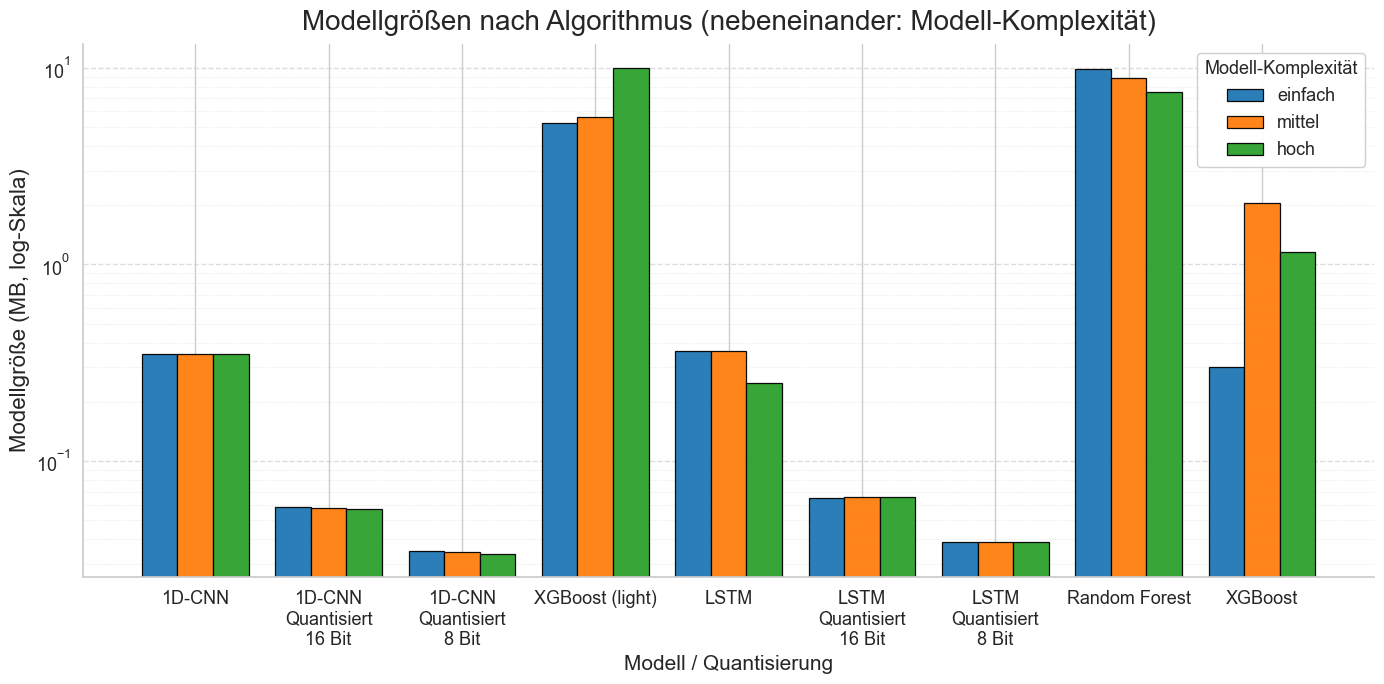

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Einheitliches Design (Farben, Schriften, Mapping) ----------------------

ALGORITHM_NAME_MAP = {
    "lstm": "LSTM",
    "gru": "GRU",
    "cnn1d": "1D-CNN",
    "cnn_1d": "1D-CNN",
    "cnn": "CNN",
    "tcn": "TCN",
    "mlp": "MLP",
    "ffn": "Feedforward NN",
    "transformer": "Transformer",
    "random_forest": "Random Forest",
    "rf": "Random Forest",
    "xgboost": "XGBoost",
    "light_xgboost": "XGBoost (light)",
    "lightxgboost": "XGBoost (light)",
    "lightgbm": "LightGBM",
    "catboost": "CatBoost",
    "linear_regression": "Linear Regression",
    "ridge": "Ridge Regression",
    "lasso": "Lasso Regression",
    "elastic_net": "Elastic Net",
    "svr": "SVR",
    "arima": "ARIMA",
    "prophet": "Prophet",
    "knn": "k-NN",
    "decision_tree": "Decision Tree",
    "dt": "Decision Tree",
    "bayesian_ridge": "Bayesian Ridge",
}

# einheitliche Farben für die Level (Modell-Komplexität)
LEVEL_PALETTE = {
    "simple": "#1f77b4",  # blau
    "medium": "#ff7f0e",  # orange
    "high":   "#2ca02c",  # grün
}

# Globale (optionale) rcParams – für alle Plots
def unified_mpl_style():
    return {
        "font.size": 13,
        "axes.titlesize": 20,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "figure.dpi": 120,
        "savefig.dpi": 300,
    }

def _alg_display(name: str) -> str:
    if pd.isna(name):
        return ""
    key = str(name).strip().lower()
    return ALGORITHM_NAME_MAP.get(key, str(name).replace("_", " ").title())

# ---- Plot-Funktion ----------------------------------------------------------

def plot_model_sizes_by_level(df: pd.DataFrame, ax=None):
    """
    Visualisiert Modellgrößen (MB) je (Algorithmus x Quantisierung) als gruppierte Balken
    mit nebeneinanderliegenden Balken für die Modell-Komplexität (einfach/mittel/hoch).
    Y-Achse: logarithmisch.

    Erwartete Spalten:
        ['algorithm', 'level', 'quant_mode', 'model_size_mb']

    Rückgabe:
        fig, ax
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 7))
    else:
        fig = ax.figure

    needed = {'algorithm', 'level', 'quant_mode', 'model_size_mb'}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Fehlende Spalten im DataFrame: {missing}")

    data = df.copy()
    data['model_size_mb'] = pd.to_numeric(data['model_size_mb'], errors='coerce')
    data = data.dropna(subset=['algorithm', 'level', 'quant_mode', 'model_size_mb'])
    data = data[data['model_size_mb'] > 0]
    if data.empty:
        raise ValueError("Keine positiven 'model_size_mb'-Werte vorhanden (für Log-Skala erforderlich).")

    # Kategorien & Labels
    level_order = ['simple', 'medium', 'high']
    level_labels_de = {'simple': 'einfach', 'medium': 'mittel', 'high': 'hoch'}
    data['level'] = pd.Categorical(data['level'], categories=level_order, ordered=True)

    quant_order = ['no-quant', 'quant-16', 'quant-8']
    extras = [q for q in data['quant_mode'].unique() if q not in quant_order]
    data['quant_mode'] = pd.Categorical(data['quant_mode'], categories=quant_order + extras, ordered=True)

    # robuste Aggregation (Median)
    g = (data
         .groupby(['algorithm', 'quant_mode', 'level'], observed=True, as_index=False)['model_size_mb']
         .median())

    # Reihenfolge: algorithm (alphabetisch), dann quant_mode
    ordering = (g[['algorithm', 'quant_mode']]
                .drop_duplicates()
                .sort_values(['algorithm', 'quant_mode'], kind='stable')
                .reset_index(drop=True))
    ordering['group_key'] = ordering['algorithm'].astype(str) + "||" + ordering['quant_mode'].astype(str)
    g['group_key'] = g['algorithm'].astype(str) + "||" + g['quant_mode'].astype(str)

    pivot = (g
             .pivot_table(index='group_key',
                          columns='level',
                          values='model_size_mb',
                          aggfunc='median',
                          observed=True)
             .reindex(columns=level_order))

    pivot = pivot.reindex(ordering['group_key']).dropna(how='all')

    x = np.arange(len(pivot.index))
    present_levels = [lvl for lvl in level_order if lvl in pivot.columns and not pivot[lvl].isna().all()]
    n_levels = max(len(present_levels), 1)
    bar_width = 0.8 / n_levels

    # Balken zeichnen: Farben aus LEVEL_PALETTE, schwarze Kanten, leicht transparent
    for i, lvl in enumerate(present_levels):
        vals = pivot[lvl].to_numpy()
        ax.bar(x + (i - (n_levels - 1) / 2) * bar_width,
               vals,
               width=bar_width,
               color=LEVEL_PALETTE.get(lvl, None),
               edgecolor='black',
               linewidth=0.9,
               alpha=0.95,
               label=level_labels_de.get(lvl, lvl))

    # Y: Log-Skala
    ax.set_yscale("log")
    finite_vals = pivot.to_numpy(dtype=float)
    finite_vals = finite_vals[np.isfinite(finite_vals)]
    if finite_vals.size:
        ymin = finite_vals.min() / 1.3
        ax.set_ylim(bottom=max(ymin, 1e-6))

    # Kräftigeres Gitter (wissenschaftlicher Look)
    ax.grid(axis='y', which='major', linestyle='--', linewidth=1.0, alpha=0.65)
    ax.grid(axis='y', which='minor', linestyle=':', linewidth=0.8, alpha=0.45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Achsenbeschriftungen & Titel
    ax.set_ylabel("Modellgröße (MB, log-Skala)", fontsize=16)
    ax.set_xlabel("Modell / Quantisierung", fontsize=15)
    ax.set_title("Modellgrößen nach Algorithmus (nebeneinander: Modell-Komplexität)", fontsize=20, pad=10)

    # X-Tick-Labels (mehrzeilig) mit Mapping der Algorithmenamen
    key_to_tuple = ordering.set_index('group_key')[['algorithm', 'quant_mode']].to_dict('index')

    def _tick_label(group_key):
        alg_raw = key_to_tuple[group_key]['algorithm']
        q = key_to_tuple[group_key]['quant_mode']
        alg = _alg_display(alg_raw)
        if q == 'no-quant' or pd.isna(q):
            return f"{alg}"
        if q == 'quant-16':
            return f"{alg}\nQuantisiert\n16 Bit"
        if q == 'quant-8':
            return f"{alg}\nQuantisiert\n8 Bit"
        return f"{alg}\n{str(q)}"

    ticklabels = [_tick_label(k) for k in pivot.index]
    ax.set_xticks(x)
    ax.set_xticklabels(ticklabels, ha='center', fontsize=13)
    ax.tick_params(axis='y', which='both', labelsize=13)

    # Legende
    leg = ax.legend(title="Modell-Komplexität", fontsize=13, title_fontsize=13, frameon=True)
    leg.get_frame().set_alpha(0.95)

    # Platz für mehrzeilige X-Labels
    fig.subplots_adjust(bottom=0.28)
    fig.tight_layout()
    return fig, ax


# --- Beispielaufruf ---
fig, ax = plot_model_sizes_by_level(df_multiconfig_edge)
plt.show()
